# Explainable Risk Prediction for Patient Readmission


This project develops an interpretable machine learning model to predict whether a diabetic patient will be readmitted to the hospital within 30 days of discharge. Using the Diabetes 130-US Hospitals dataset, the project focuses on building a trustworthy prediction pipeline by addressing data quality issues, preventing patient-level data leakage, and handling class imbalance.

A Logistic Regression baseline is compared with an XGBoost model to measure performance improvements. Model predictions are explained using SHAP to provide both global and patient-level insights into the factors driving readmission risk.


## Libraries

* **Pandas** – Data loading, cleaning, preprocessing, and analysis.
* **NumPy** – Numerical computations and array operations.
* **Matplotlib** – Data visualization and exploratory analysis plots.
* **Scikit-learn** – Data preprocessing, train/test splitting, Logistic Regression baseline model, and evaluation metrics.
* **XGBoost** – Main machine learning model for predicting 30-day hospital readmission risk.
* **SHAP** – Model explainability, feature importance analysis, and individual prediction explanations.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('diabetic_data.csv')

In [6]:
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [7]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [9]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [10]:
df.shape

(101766, 50)

## Columns in the Dataset

* `readmitted` – Target variable used to predict 30-day hospital readmission.
* `patient_nbr` – Patient identifier used to detect and prevent data leakage during train/test splitting.
* `race`, `gender`, `age` – Demographic features and sensitive attributes for fairness analysis.
* `time_in_hospital` – Length of hospital stay.
* `num_lab_procedures`, `num_medications` – Indicators of treatment intensity and patient complexity.
* `number_outpatient`, `number_emergency`, `number_inpatient` – Previous healthcare utilization, often strong predictors of readmission.
* `number_diagnoses` – Number of diagnoses recorded during the encounter.
* `diag_1`, `diag_2`, `diag_3` – Primary and secondary diagnosis codes.
* `insulin`, `change`, `diabetesMed` – Diabetes medication and treatment-related features.
* `admission_type_id`, `discharge_disposition_id`, `admission_source_id` – Admission and discharge information that may influence readmission risk.


# Exploratory Data Analysis(EDA)

In [11]:
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [12]:
df.isnull()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
101762,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
101763,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
101764,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [13]:
df.isnull().sum()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazo

In [14]:
df = df.replace('?', np.nan)

In [15]:
df.isnull().sum().sort_values(ascending=False)

weight                      98569
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
encounter_id                    0
tolazamide                      0
glyburide                       0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
troglitazone                    0
citoglipton                     0
examide                         0
acetohexamide                   0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
diabetesMed                     0
glipizide                       0
repaglinide                     0
glimepiride   

In [16]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct.sort_values(ascending=False)

weight                      96.858479
medical_specialty           49.082208
payer_code                  39.557416
race                         2.233555
diag_3                       1.398306
diag_2                       0.351787
diag_1                       0.020636
encounter_id                 0.000000
tolazamide                   0.000000
glyburide                    0.000000
tolbutamide                  0.000000
pioglitazone                 0.000000
rosiglitazone                0.000000
acarbose                     0.000000
miglitol                     0.000000
troglitazone                 0.000000
citoglipton                  0.000000
examide                      0.000000
acetohexamide                0.000000
insulin                      0.000000
glyburide-metformin          0.000000
glipizide-metformin          0.000000
glimepiride-pioglitazone     0.000000
metformin-rosiglitazone      0.000000
metformin-pioglitazone       0.000000
change                       0.000000
diabetesMed 

In [17]:
df['race'] = df['race'].fillna('Unknown')
df['diag_1'] = df['diag_1'].fillna('Unknown')
df['diag_2'] = df['diag_2'].fillna('Unknown')
df['diag_3'] = df['diag_3'].fillna('Unknown')

In [18]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [19]:
df = df.drop(
    columns=[
        'weight',
        'max_glu_serum',
        'A1Cresult',
        'medical_specialty',
        'payer_code'
    ]
)

In [20]:
df.isnull().sum().sum()

0

In [21]:
df.duplicated().sum()

0

In [22]:
df.nunique().sort_values(ascending=False)

encounter_id                101766
patient_nbr                  71518
diag_3                         790
diag_2                         749
diag_1                         717
num_lab_procedures             118
num_medications                 75
number_outpatient               39
number_emergency                33
discharge_disposition_id        26
number_inpatient                21
admission_source_id             17
number_diagnoses                16
time_in_hospital                14
age                             10
admission_type_id                8
num_procedures                   7
race                             6
glyburide                        4
glyburide-metformin              4
insulin                          4
miglitol                         4
acarbose                         4
rosiglitazone                    4
pioglitazone                     4
chlorpropamide                   4
glipizide                        4
glimepiride                      4
nateglinide         

In [23]:
df['citoglipton'].value_counts()

No    101766
Name: citoglipton, dtype: int64

In [24]:
df['examide'].value_counts()

No    101766
Name: examide, dtype: int64

In [25]:
df = df.drop(columns=['citoglipton', 'examide'])

## Data Cleaning Summary
The dataset was examined for missing values, duplicate records, and feature cardinality. Missing values represented by `"?"` were converted to `NaN` and analyzed. Several features (`weight`, `max_glu_serum`, `A1Cresult`, `medical_specialty`, and `payer_code`) contained substantial missingness and were removed from the dataset. Features with low levels of missing data (`race`, `diag_1`, `diag_2`, and `diag_3`) were retained and missing values were replaced with an `"Unknown"` category.

No duplicate records were detected in the dataset. Cardinality analysis identified `encounter_id` and `patient_nbr` as identifier variables with a large number of unique values, indicating that they should not be used directly for prediction. Diagnosis-related variables (`diag_1`, `diag_2`, and `diag_3`) also exhibited high cardinality and will require appropriate preprocessing during modeling.

Finally, `citoglipton` and `examide` were removed because they contained only a single unique value and therefore provided no predictive information.


## Target Variable Analysis

The objective of this project is to predict whether a diabetic patient will be readmitted within 30 days of discharge. Therefore, the `readmitted` variable is examined to understand its distribution and determine how it should be framed for the prediction task.


In [26]:
df['readmitted'].value_counts()

NO     54864
>30    35545
<30    11357
Name: readmitted, dtype: int64

In [27]:
(df['readmitted'].value_counts(normalize=True) * 100)

NO     53.911916
>30    34.928169
<30    11.159916
Name: readmitted, dtype: float64

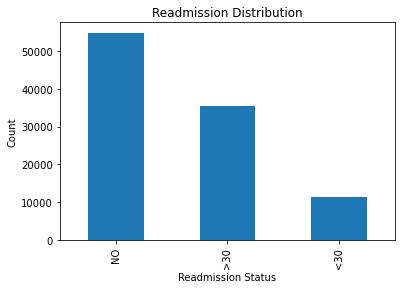

In [28]:
df['readmitted'].value_counts().plot(kind='bar')
plt.title('Readmission Distribution')
plt.xlabel('Readmission Status')
plt.ylabel('Count')
plt.show()

### Target Framing Decision

The `readmitted` variable contains three categories: `NO`, `>30`, and `<30`. Since the objective is to predict early hospital readmission, the problem is framed as a binary classification task where `<30` is the positive class and all other outcomes are treated as the negative class.

The target distribution shows that early readmissions are less frequent than non-readmissions, indicating class imbalance that will be considered during model development and evaluation.


In [29]:
df['target'] = (df['readmitted'] == '<30').astype(int)

In [30]:
df['target'].value_counts()

0    90409
1    11357
Name: target, dtype: int64

In [31]:
(df['target'].value_counts(normalize=True) * 100)

0    88.840084
1    11.159916
Name: target, dtype: float64

### Binary Target Distribution

The target variable was transformed into a binary classification problem, where patients readmitted within 30 days (`<30`) were assigned a value of 1 and all other cases (`NO` and `>30`) were assigned a value of 0.

The resulting distribution shows that positive cases represent a smaller proportion of the dataset, confirming the presence of class imbalance. This will be considered during model training through techniques such as class weighting or resampling, and performance will be evaluated using metrics that are appropriate for imbalanced datasets.


## Leakage Analysis

Before model development, the relationship between encounters and patients is examined to identify potential data leakage. Since a patient may have multiple hospital encounters, it is important to determine whether the same patient appears multiple times in the dataset.

In [32]:
print("Total encounters:", len(df))

Total encounters: 101766


In [33]:
print("Unique patients:", df['patient_nbr'].nunique())

Unique patients: 71518


In [34]:
df['patient_nbr'].duplicated().sum()

30248

In [35]:
(df['patient_nbr'].value_counts() > 1).sum()

16773

## Leakage Assessment

The dataset contains 101,766 encounters but only 71,518 unique patients, meaning some patients appear multiple times. This creates a potential data leakage risk if the same patient appears in both training and testing data. Therefore, `encounter_id` and `patient_nbr` will not be used as predictive features. A copy of `patient_nbr` will be retained for patient-level train/test splitting, after which both identifier columns will be removed from the modeling dataset.


In [36]:
patient_ids = df['patient_nbr']

In [37]:
df = df.drop(columns=['encounter_id', 'patient_nbr'])

## Feature Exploration
Before building the predictive models, key demographic and clinical features are explored to better understand the patient population and identify variables that may influence hospital readmission risk.


In [38]:
df['age'].value_counts()

[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: age, dtype: int64

In [39]:
df['gender'].value_counts()

Female             54708
Male               47055
Unknown/Invalid        3
Name: gender, dtype: int64

In [40]:
df['race'].value_counts()

Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: race, dtype: int64

In [41]:
df['time_in_hospital'].describe()

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64

In [42]:
df['number_inpatient'].describe()

count    101766.000000
mean          0.635566
std           1.262863
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          21.000000
Name: number_inpatient, dtype: float64

In [43]:
df['number_emergency'].describe()

count    101766.000000
mean          0.197836
std           0.930472
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          76.000000
Name: number_emergency, dtype: float64

In [44]:
df['number_outpatient'].describe()

count    101766.000000
mean          0.369357
std           1.267265
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          42.000000
Name: number_outpatient, dtype: float64

In [45]:
df['num_medications'].describe()

count    101766.000000
mean         16.021844
std           8.127566
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          81.000000
Name: num_medications, dtype: float64

In [46]:
df['num_lab_procedures'].describe()

count    101766.000000
mean         43.095641
std          19.674362
min           1.000000
25%          31.000000
50%          44.000000
75%          57.000000
max         132.000000
Name: num_lab_procedures, dtype: float64

In [47]:
df['num_procedures'].describe()

count    101766.000000
mean          1.339730
std           1.705807
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: num_procedures, dtype: float64

## Feature Exploration Summary

The dataset is dominated by older patients, with the majority of encounters occurring in the 60–80 and 70–80 age groups. Patients received an average of 16 medications during hospitalization, indicating substantial treatment complexity. On average, approximately 43 laboratory procedures were performed per encounter, while the number of medical procedures was relatively low, with a median of one procedure per patient. These variables may provide valuable information for predicting early hospital readmission risk.


## Data Preparation

Before model training, the dataset is prepared by separating features and the target variable, encoding categorical variables, and creating training and testing datasets. These steps ensure that the data is in a suitable format for machine learning algorithms.


In [48]:
X = df.drop(columns=['readmitted', 'target'])
y = df['target']

In [49]:
categorical_cols = X.select_dtypes(include='object').columns
print(categorical_cols)

Index(['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed'],
      dtype='object')


In [50]:
X = pd.get_dummies(X, drop_first=True)

In [51]:
X.shape

(101766, 2330)

## Data Preparation Summary

The dataset was prepared for machine learning by separating the predictor variables (`X`) from the target variable (`y`). The original `readmitted` column and the derived binary target were excluded from the feature set to prevent target leakage. Categorical variables were identified and converted into numerical representations using one-hot encoding, ensuring compatibility with machine learning algorithms.

After preprocessing, the dataset contained 101,766 observations and 2,330 features. The large number of features is mainly due to the high-cardinality diagnosis variables (`diag_1`, `diag_2`, and `diag_3`). The resulting dataset is now ready for train-test splitting, class imbalance handling, and model development.


## Train-Test Split and Class Imbalance Handling

The data is prepared for model training by splitting it into training and testing sets. The target distribution is checked to understand class imbalance, and a patient-level split is used to prevent data leakage.

In [52]:
y.value_counts()

0    90409
1    11357
Name: target, dtype: int64

In [53]:
y.value_counts(normalize=True) * 100

0    88.840084
1    11.159916
Name: target, dtype: float64

The target distribution shows a clear class imbalance. Most encounters belong to the negative class (88.84%), while early readmission cases represent only 11.16% of the data. Therefore, class imbalance will be considered during model training to reduce bias toward the majority class.


## Patient-Level Train-Test Split

A patient-level train-test split is used to prevent data leakage. Since some patients have multiple hospital encounters, the same patient should not appear in both training and testing sets. `GroupShuffleSplit` is used with `patient_ids` as the grouping variable to keep all encounters from the same patient together.

In [54]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=patient_ids)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [55]:
X_train.shape, X_test.shape

((81613, 2330), (20153, 2330))

In [56]:
y_train.value_counts()

0    72407
1     9206
Name: target, dtype: int64

In [57]:
y_test.value_counts()

0    18002
1     2151
Name: target, dtype: int64

The split preserved both classes in the training and testing sets, allowing the model to be trained and evaluated while maintaining a realistic class distribution.

## Class Imbalance Handling

The target variable is imbalanced because early readmission cases represent a smaller portion of the dataset. Class weights will be calculated to give more importance to the minority class during model training and reduce bias toward the majority class.

In [58]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

weights

array([0.5635712 , 4.43259831])

In [59]:
class_weights = {
    0: weights[0],
    1: weights[1]
}

class_weights

{0: 0.5635712016793957, 1: 4.432598305452966}

The calculated class weights will be used during model training. This helps the models pay more attention to early readmission cases, which are less frequent in the dataset.

## Train-Test Split and Class Imbalance Summary

The dataset was split into training and testing sets using a patient-level split to prevent data leakage. The training set contains **81,613 encounters** and the testing set contains **20,153 encounters**. The split kept patients separated between the two sets, ensuring a more realistic evaluation.

The target variable showed class imbalance, with **90,409 negative cases (88.84%)** and **11,357 early readmission cases (11.16%)**. To address this imbalance, class weights were calculated. The minority class received a higher weight (**4.43**) compared to the majority class (**0.56**), allowing the model to give more attention to early readmission cases during training.

The processed dataset is now ready for model development.


## Model Development

The prepared dataset is used to train **machine learning models** for predicting **early hospital readmission**. A **Logistic Regression** model is developed as a baseline, followed by an **XGBoost** model. The performance of both models will be compared using **classification metrics** to identify the most effective approach.


## Logistic Regression Model

A **Logistic Regression** model is trained as a baseline classifier for predicting **early hospital readmission**. Class weights are incorporated to address the class imbalance identified in the previous phase and improve the model's ability to detect minority-class cases.


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight=class_weights,
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1-score: {f1_score(y_test, y_pred):.2f}")

In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.65      0.76     18002
           1       0.15      0.53      0.24      2151

    accuracy                           0.64     20153
   macro avg       0.54      0.59      0.50     20153
weighted avg       0.84      0.64      0.71     20153



In [64]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[11684,  6318],
       [ 1016,  1135]])

### Logistic Regression Evaluation

The Logistic Regression model achieved a **precision of 17%**, **recall of 54%**, and **F1-score of 25%**.

The results show that the model was able to identify more than half of the patients who were readmitted within 30 days. The low precision indicates that many patients predicted as high risk were not actually readmitted.

Overall, the model is better at detecting early readmission cases, but there is still room for improvement. A more advanced model, **XGBoost**, will be evaluated next to achieve a better balance between precision and recall.


## Logistic Regression Evaluation

The Logistic Regression model achieved a **precision of 17%**, **recall of 54%**, and **F1-score of 25%**.

The results show that the model was able to identify more than half of the patients who were readmitted within 30 days. This is a significant improvement compared to the previous model. However, the low precision indicates that many patients predicted as high risk were not actually readmitted.

Overall, the model is better at detecting early readmission cases, but there is still room for improvement. A more advanced model, **XGBoost**, will be evaluated next to achieve a better balance between precision and recall.


In [ ]:
from xgboost import XGBClassifier

In [ ]:
scale_pos_weight = 72407 / 9206
scale_pos_weight

## Feature Name Correction

Some encoded feature names contained special characters (`[` and `]`) from the age categories. Since XGBoost does not support these characters in column names, the feature names were cleaned before model training.


In [68]:
import re

X_train.columns = [re.sub(r'[^A-Za-z0-9_]', '_', str(c)) for c in X_train.columns]
X_test.columns = [re.sub(r'[^A-Za-z0-9_]', '_', str(c)) for c in X_test.columns]

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

In [ ]:
xgb_model.fit(X_train, y_train)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.2f}")
print(f"F1-score: {f1_score(y_test, y_pred_xgb):.2f}")

In [81]:
print(classification_report(y_test, y_pred_xgb))
confusion_matrix(y_test, y_pred_xgb)

              precision    recall  f1-score   support

           0       0.93      0.66      0.77     18002
           1       0.17      0.57      0.26      2151

    accuracy                           0.65     20153
   macro avg       0.55      0.62      0.52     20153
weighted avg       0.85      0.65      0.72     20153



array([[11950,  6052],
       [  915,  1236]])

## XGBoost Evaluation

The **XGBoost** model achieved slightly higher **recall** and **F1-score** than **Logistic Regression**, indicating a better ability to identify early readmission cases. However, the improvement was modest, and the model still struggled with the minority class.

The results suggest that class imbalance continues to influence model performance, as the number of early readmission cases is much smaller than the number of non-readmission cases. Although imbalance-handling techniques improved detection of the minority class, predicting early readmissions remains a challenging task.


## Baseline Comparison

To check whether XGBoost improves performance, a simple **Logistic Regression** model was used as a baseline. Logistic Regression provides a basic comparison to see if the more advanced XGBoost model performs better.

| Metric | Logistic Regression | XGGBoost |
|---|---:|---:|
| Accuracy | 0.65 | 0.65 |
| Precision | 0.17 | 0.17 |
| Recall | 0.54 | 0.57 |
| F1-score | 0.25 | 0.26 |

The results show that both models have the same accuracy. However, XGBoost performs slightly better in **recall** and **F1-score**, meaning it can identify a few more positive cases than Logistic Regression.

## Model Evaluation

The dataset has an imbalanced class distribution, so accuracy alone is not enough to judge model performance. A model can get good accuracy by mostly predicting the majority class.

Therefore, **precision, recall, and F1-score** were used:

- **Precision:** Shows how many predicted positive cases were actually correct.
- **Recall:** Shows how many actual positive cases the model was able to find.
- **F1-score:** Gives a balance between precision and recall.

Overall, XGBoost gives a small improvement compared to Logistic Regression. The higher recall and F1-score show that XGBoost is slightly better at finding positive cases.

## Model Interpretability with SHAP

To better understand how the **XGBoost** model makes predictions, **SHAP (SHapley Additive exPlanations)** is used. **SHAP** provides both global and local explanations, helping identify the features that have the greatest influence on model predictions.


In [83]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 11.1 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [numpy]  WARNING: The scripts f2py and numpy-config are installed in '/home/4336f987-c19d-400e-9335-ff4de38d9c09/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]━━━━━━━ 2/3 [shap]]


In [84]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

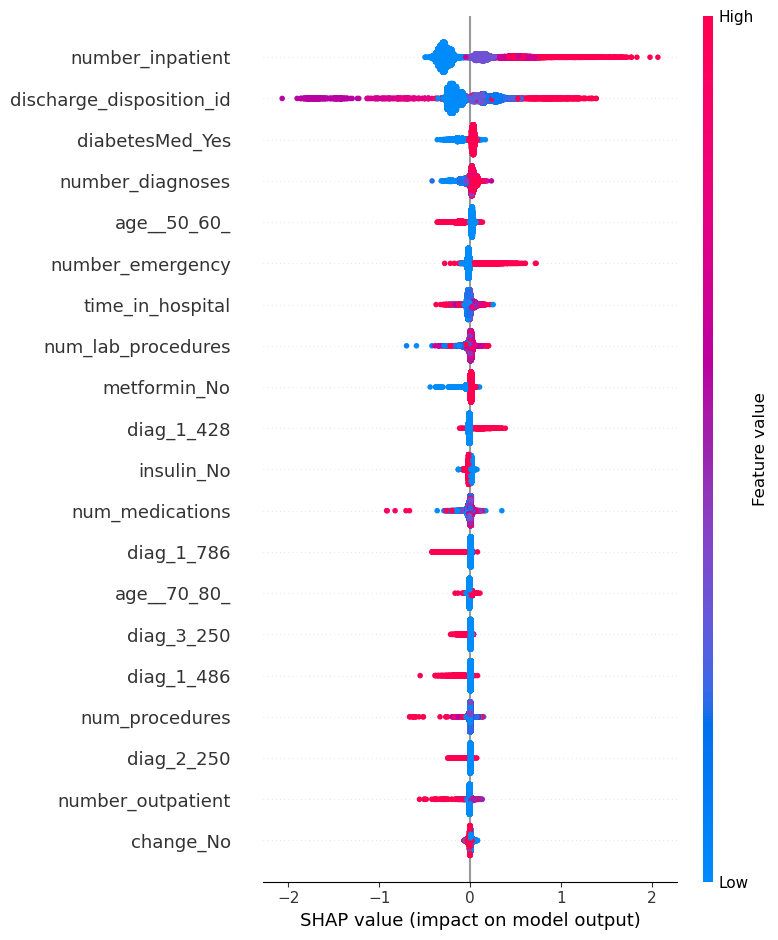

In [85]:
shap.summary_plot(shap_values, X_test)

## Global Explanation

SHAP helps us understand which features are most important for the model's predictions across all patients.

The SHAP summary plot shows that the model mainly relies on:

* `number_inpatient`
* `discharge_disposition_id`
* `diabetesMed_Yes`
* `number_diagnoses`
* `number_emergency`
* `time_in_hospital`

Patients with more previous inpatient visits, more diagnoses, more emergency visits, and longer hospital stays generally have a higher predicted risk of readmission. These features have the largest impact on the model's decisions.

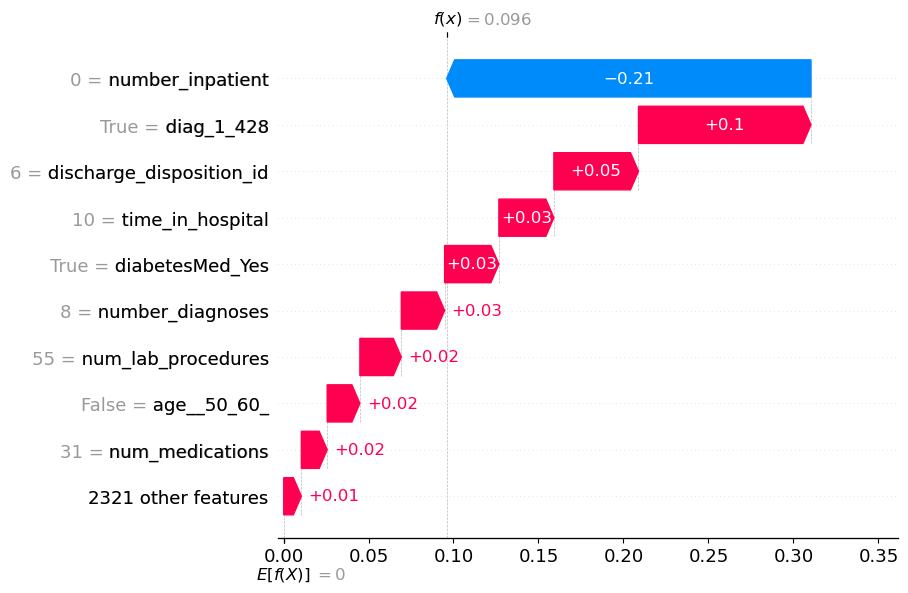

In [88]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

## Local Explanation (Individual Prediction)

The SHAP waterfall plot explains one specific prediction.

For this patient, the strongest factors increasing the predicted risk were:

* Primary diagnosis (`diag_1_428`)
* Discharge disposition (`discharge_disposition_id`)
* Longer hospital stay (`time_in_hospital`)
* Diabetes medication usage (`diabetesMed_Yes`)
* Higher number of diagnoses

The strongest factor reducing the predicted risk was:

* No previous inpatient admissions (`number_inpatient = 0`)

Overall, although several factors increased the patient's risk, having no prior inpatient admissions significantly lowered the final prediction.


## Critical Insight

The SHAP results show that the model mainly uses meaningful healthcare-related information, such as previous inpatient visits, number of diagnoses, and length of hospital stay. These factors are reasonable indicators of a patient's risk of readmission.

The feature **discharge_disposition_id** was also important in the model. Since it contains discharge-related information, it should be checked carefully to ensure that it does not introduce data leakage.


## Fairness Analysis

Fairness analysis was conducted to examine whether the model performs consistently across different demographic groups. This helps identify potential differences in model performance that may affect specific patient populations.


In [124]:
patient_gender = df.loc[X_test.index, 'gender']

female_mask = patient_gender == 'Female'
male_mask = patient_gender == 'Male'

In [125]:
print(f"Female Recall: {recall_score(y_test[female_mask], y_pred_xgb[female_mask]):.2f}")
print(f"Male Recall: {recall_score(y_test[male_mask], y_pred_xgb[male_mask]):.2f}")

Female Recall: 0.59
Male Recall: 0.55


In [109]:
patient_race = df.loc[X_test.index, 'race']

for race in patient_race.dropna().unique():
    mask = patient_race == race

    if y_test[mask].sum() > 0:
        recall = recall_score(
            y_test[mask],
            y_pred_xgb[mask]
        )

        print(f"{race}: {recall:.2f}")

Caucasian: 0.59
AfricanAmerican: 0.55
Other: 0.45
Unknown: 0.48
Hispanic: 0.58
Asian: 0.32


In [110]:
patient_age = df.loc[X_test.index, 'age']

for age in patient_age.unique():
    mask = patient_age == age

    if y_test[mask].sum() > 0:
        recall = recall_score(
            y_test[mask],
            y_pred_xgb[mask]
        )

        print(f"{age}: {recall:.2f}")

[80-90): 0.62
[70-80): 0.63
[60-70): 0.56
[50-60): 0.48
[40-50): 0.60
[30-40): 0.49
[90-100): 0.53
[20-30): 0.43
[10-20): 0.40
[0-10): 0.00


## Fairness Analysis

The model's performance was evaluated across gender, race, and age groups using recall.

For gender, the recall was **59%** for female patients and **55%** for male patients, showing similar performance across genders.

For race, recall values were generally similar across the larger racial groups, although lower recall was observed for some smaller groups.

For age, the model performed better for older patients and less effectively for some younger age groups.

Overall, the results suggest that the model performs reasonably consistently across different demographic groups, although some variation is present.
